# 08 - Model Comparison

Loads all four ISOT models and evaluates on the held-out test set.
Outputs are saved to `reports/08_comparison/`.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "08_comparison"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")


In [2]:
X_test = joblib.load(DATA_DIR / "X_test_tfidf.pkl")
y_test = np.array(joblib.load(DATA_DIR / "y_test.pkl"))

models = {
    "Naive Bayes": joblib.load(MODELS_DIR / "naive_bayes_model.pkl"),
    "Logistic Regression": joblib.load(MODELS_DIR / "lr_model.pkl"),
    "SVM (LinearSVC)": joblib.load(MODELS_DIR / "svm_model.pkl"),
    "Random Forest": joblib.load(MODELS_DIR / "rf_model.pkl"),
}

print("X_test:", X_test.shape)
for name, model in models.items():
    print(name, "n_features_in_=", getattr(model, "n_features_in_", None))
    if getattr(model, "n_features_in_", X_test.shape[1]) != X_test.shape[1]:
        raise ValueError(f"{name} is incompatible with X_test feature count.")


c:\Users\nguye\Documents\GitHub\Fake-News-Detection\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\nguye\Documents\GitHub\Fake-News-Detection\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


X_test: (5798, 10000)
Naive Bayes n_features_in_= 10000
Logistic Regression n_features_in_= 10000
SVM (LinearSVC) n_features_in_= 10000
Random Forest n_features_in_= 10000


In [3]:
report_dirs = {
    "Naive Bayes": ROOT / "reports" / "04_naive_bayes" / "metrics.json",
    "Logistic Regression": ROOT / "reports" / "05_logistic_regression" / "metrics.json",
    "SVM (LinearSVC)": ROOT / "reports" / "06_svm" / "metrics.json",
    "Random Forest": ROOT / "reports" / "07_random_forest" / "metrics.json",
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    train_time = None
    if report_dirs[name].exists():
        with open(report_dirs[name], "r", encoding="utf-8") as f:
            train_time = json.load(f).get("training_time_seconds")

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "training_time_seconds": train_time,
    })

comparison = pd.DataFrame(rows).sort_values("f1_weighted", ascending=False)
comparison.to_csv(REPORT_DIR / "test_metrics.csv", index=False)
display(comparison)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
2,SVM (LinearSVC),0.986547,0.986561,0.986547,0.986542,12.641003
1,Logistic Regression,0.983443,0.983484,0.983443,0.983433,39.680705
3,Random Forest,0.974819,0.974999,0.974819,0.974789,600.336073
0,Naive Bayes,0.950155,0.950144,0.950155,0.950148,2.429468


C:\Users\nguye\AppData\Local\Temp\ipykernel_15816\3506084148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="model", y="f1_weighted", palette="viridis")


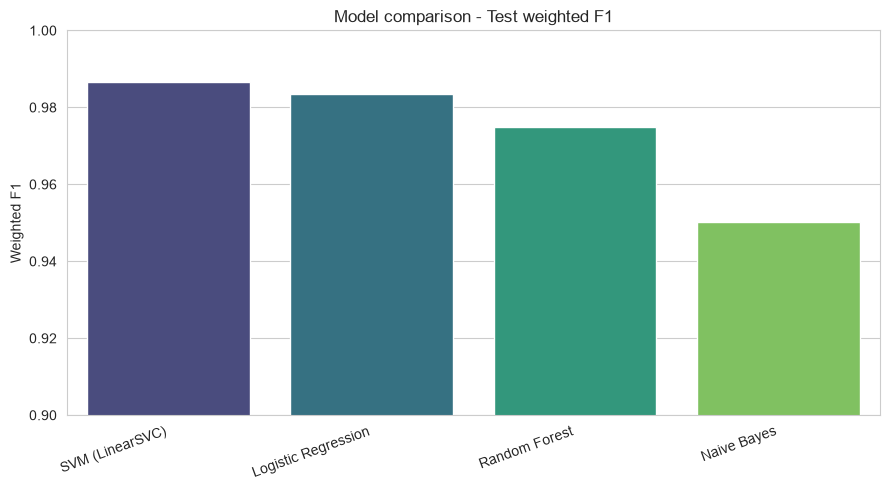

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="model", y="f1_weighted", palette="viridis")
plt.ylim(0.90, 1.00)
plt.title("Model comparison - Test weighted F1")
plt.xlabel("")
plt.ylabel("Weighted F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "comparison_f1_score.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "comparison_f1_score.png", dpi=150, bbox_inches="tight")
plt.show()

with open(REPORT_DIR / "comparison_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_model": comparison.iloc[0]["model"],
            "best_f1_weighted": float(comparison.iloc[0]["f1_weighted"]),
            "rows": comparison.to_dict(orient="records"),
        },
        f,
        indent=2,
        ensure_ascii=False,
    )
